In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [3]:
fund_master = pd.read_csv("../data/processed/01_fund_master_cleaned.csv")
nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")
aum = pd.read_csv("../data/processed/03_aum_by_fund_house_cleaned.csv")
sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_cleaned.csv")
category = pd.read_csv("../data/processed/05_category_inflows_cleaned.csv")
folio = pd.read_csv("../data/processed/06_industry_folio_count_cleaned.csv")
performance = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")
transactions = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv")
holdings = pd.read_csv("../data/processed/09_portfolio_holdings_cleaned.csv")
benchmark = pd.read_csv("../data/processed/10_benchmark_indices_cleaned.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [4]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [5]:
nav.shape

(46000, 3)

In [6]:
nav["date"] = pd.to_datetime(nav["date"])

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022-2026)"
)

# Bull Run Area
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    annotation_text="2023 Bull Run",
    line_width=0
)

# Correction Area
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-06-30",
    fillcolor="red",
    opacity=0.15,
    annotation_text="2024 Correction",
    line_width=0
)

fig.show()

Insight 1

Most mutual fund schemes exhibited a positive long-term NAV growth trend between 2022 and 2026. A few schemes significantly outperformed others, resulting in noticeably higher NAV values.

In [7]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [8]:
aum.columns

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')

In [9]:
aum["date"] = pd.to_datetime(aum["date"])

aum["year"] = aum["date"].dt.year

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


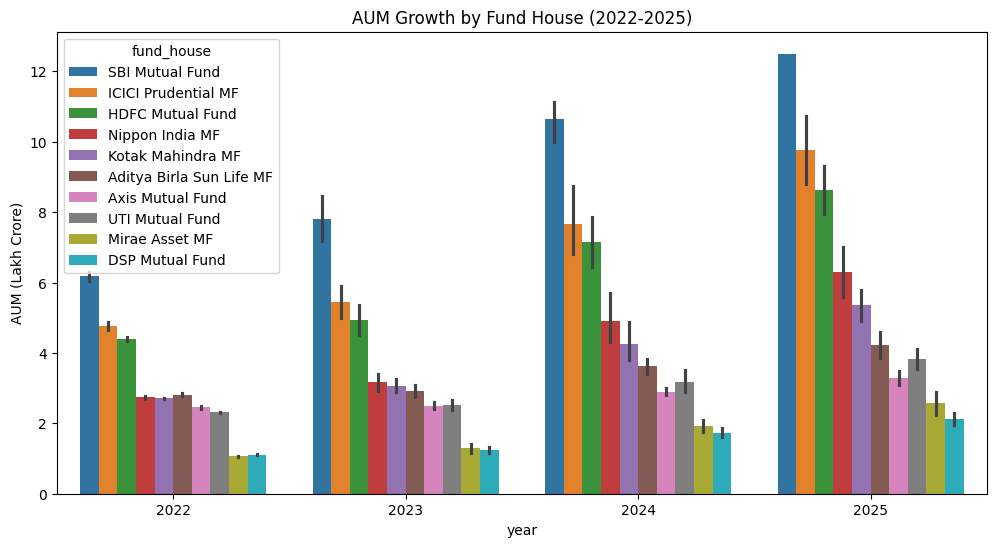

In [10]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=0)

plt.show()

In [11]:
aum.sort_values(
    by="aum_lakh_crore",
    ascending=False
).head(10)

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
70,2025-03-31,SBI Mutual Fund,12.50,1250000,186,2025
80,2025-12-31,SBI Mutual Fund,12.50,1250000,186,2025
60,2024-12-31,SBI Mutual Fund,11.14,1114000,186,2024
50,2024-09-30,SBI Mutual Fund,10.80,1080000,186,2024
81,2025-12-31,ICICI Prudential MF,10.74,1074000,216,2025
40,2024-03-31,SBI Mutual Fund,10.00,1000000,186,2024
82,2025-12-31,HDFC Mutual Fund,9.30,930000,195,2025
71,2025-03-31,ICICI Prudential MF,8.80,880000,216,2025
61,2024-12-31,ICICI Prudential MF,8.74,874000,216,2024
30,2023-09-30,SBI Mutual Fund,8.45,845000,186,2023


Insight 2

SBI Mutual Fund emerged as the market leader with the highest AUM of ₹12.5 lakh crore in 2025. ICICI Prudential and HDFC Mutual Fund followed as the second and third largest fund houses respectively.

In [12]:
aum.sort_values(
    by="aum_lakh_crore",
    ascending=False
).head(10)

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
70,2025-03-31,SBI Mutual Fund,12.50,1250000,186,2025
80,2025-12-31,SBI Mutual Fund,12.50,1250000,186,2025
60,2024-12-31,SBI Mutual Fund,11.14,1114000,186,2024
50,2024-09-30,SBI Mutual Fund,10.80,1080000,186,2024
81,2025-12-31,ICICI Prudential MF,10.74,1074000,216,2025
40,2024-03-31,SBI Mutual Fund,10.00,1000000,186,2024
82,2025-12-31,HDFC Mutual Fund,9.30,930000,195,2025
71,2025-03-31,ICICI Prudential MF,8.80,880000,216,2025
61,2024-12-31,ICICI Prudential MF,8.74,874000,216,2024
30,2023-09-30,SBI Mutual Fund,8.45,845000,186,2023


In [13]:
plt.savefig(
    "../reports/aum_growth_chart.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [14]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [15]:
sip.columns

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')

In [16]:
sip["month"] = pd.to_datetime(sip["month"])

sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


In [22]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (2022-2025)"
)

peak = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=str(peak["month"]),      # Convert to string
    y=peak["sip_inflow_crore"],
    text=f"Peak: ₹{peak['sip_inflow_crore']} Cr",
    showarrow=True
)

fig.show()

In [18]:
sip.sort_values(
    by="sip_inflow_crore",
    ascending=False
).head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
47,2025-12-01,31002,9.35,9.80,15.90,17.17
46,2025-11-01,30200,9.20,9.10,15.72,19.27
45,2025-10-01,29529,9.10,9.45,15.55,16.61
44,2025-09-01,29361,9.00,10.50,15.38,19.80
42,2025-07-01,28464,8.75,10.20,14.05,22.00


In [19]:
fig.write_image(
    "../reports/sip_trend_chart.png"
)

Wait expired, Browser is being closed by watchdog.
Temporary dictory couldn't be removed manually.


BrowserFailedError: ('The browser seemed to close immediately after starting.', 'You can set the `logging.Logger` level lower to see more output.', 'You may try installing a known working copy of Chrome by running ', '`$ choreo_get_chrome`.It may be your browser auto-updated and will now work upon restart. The browser we tried to start is located at C:\\Program Files (x86)\\Google\\Chrome\\Application\\chrome.exe.')

In [ ]:
pip install kaleido

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   ---------------------------------------- 0/5 [simplejson]
   -------- ------------------------------- 1/5 [orjson]
   -------- ------------------------------- 1/5 [orjson]
   ---------------- ----------------------- 2/5 [logistro]
   ------------------------ --------------- 3/5 [choreographer]
   ------------------------ --------------- 3/5 [choreographer]
   ------------------------ --------------- 3/5 [choreographer]
   ------------------------ --------------- 3/5 [choreographer]
   ------------------------ --------------- 3/5 [choreographer]
   ---------------

In [ ]:
fig.write_image(
    "../reports/sip_trend_chart.png"
)

ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


In [23]:
fig.write_image(
    "../reports/sip_trend_chart.png",
    width=1200,
    height=600
)

Resorting to unclean kill browser.


In [25]:
category.head()
category.columns

Index(['month', 'category', 'net_inflow_crore'], dtype='str')

In [26]:
heatmap_data = category.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore",
    aggfunc="sum"
)

heatmap_data.head()

month,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


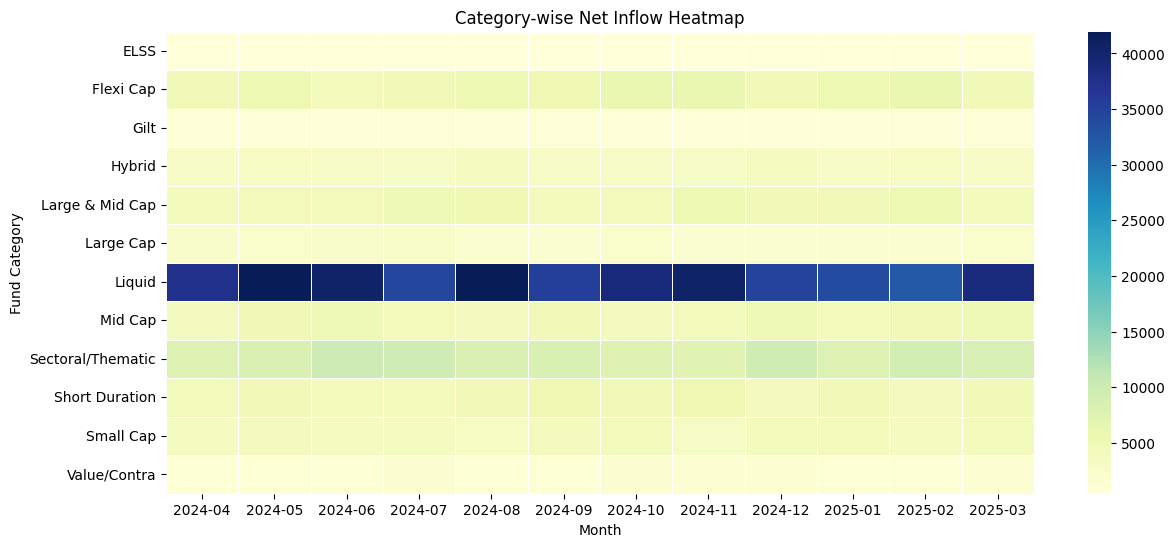

In [27]:
plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.show()

Insight 4

Net inflows varied significantly across fund categories. Certain categories consistently attracted higher investor inflows, indicating stronger investor preference during the analysis period.

In [29]:
plt.savefig(
    "../reports/category_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [30]:
transactions.columns
transactions[["age_group","gender","amount_inr","city_tier"]].head()

,age_group,gender,amount_inr,city_tier
0,56+,Female,1834,T30
1,18-25,Male,392882,B30
2,36-45,Male,912,B30
3,36-45,Female,1102,T30
4,26-35,Male,8682,T30


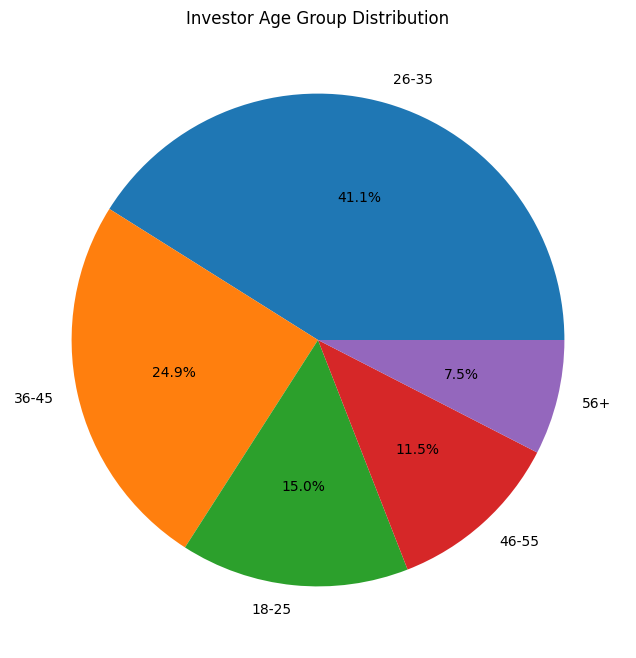

In [31]:
age_dist = transactions["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_dist,
    labels=age_dist.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.show()

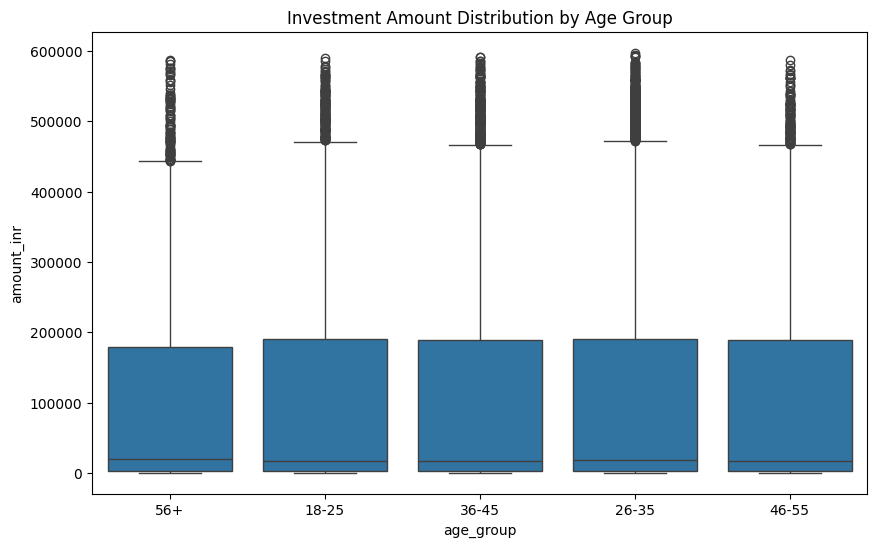

In [32]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount Distribution by Age Group")

plt.show()

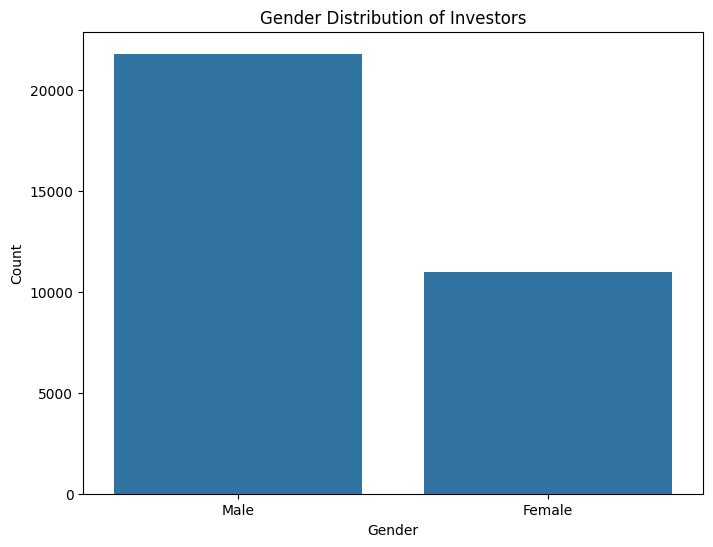

In [33]:
gender_dist = transactions["gender"].value_counts()

plt.figure(figsize=(8,6))

sns.barplot(
    x=gender_dist.index,
    y=gender_dist.values
)

plt.title("Gender Distribution of Investors")

plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

In [34]:
plt.savefig("../reports/age_distribution.png")

<Figure size 640x480 with 0 Axes>

In [35]:
plt.savefig("../reports/age_boxplot.png")

<Figure size 640x480 with 0 Axes>

In [36]:
plt.savefig("../reports/gender_distribution.png")

<Figure size 640x480 with 0 Axes>

Insight 5

The majority of investors belonged to the middle-age segments, indicating stronger participation from working professionals.

Insight 6

Investment amounts varied across age groups, with some groups showing significantly higher median investment values.

Insight 7

Investor participation was unevenly distributed across genders, highlighting demographic differences in mutual fund adoption.

In [37]:
state_investment = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

state_investment.head()

state
Punjab            315780459
Tamil Nadu        315177237
Madhya Pradesh    308312493
Rajasthan         298645822
Gujarat           298358940
Name: amount_inr, dtype: int64

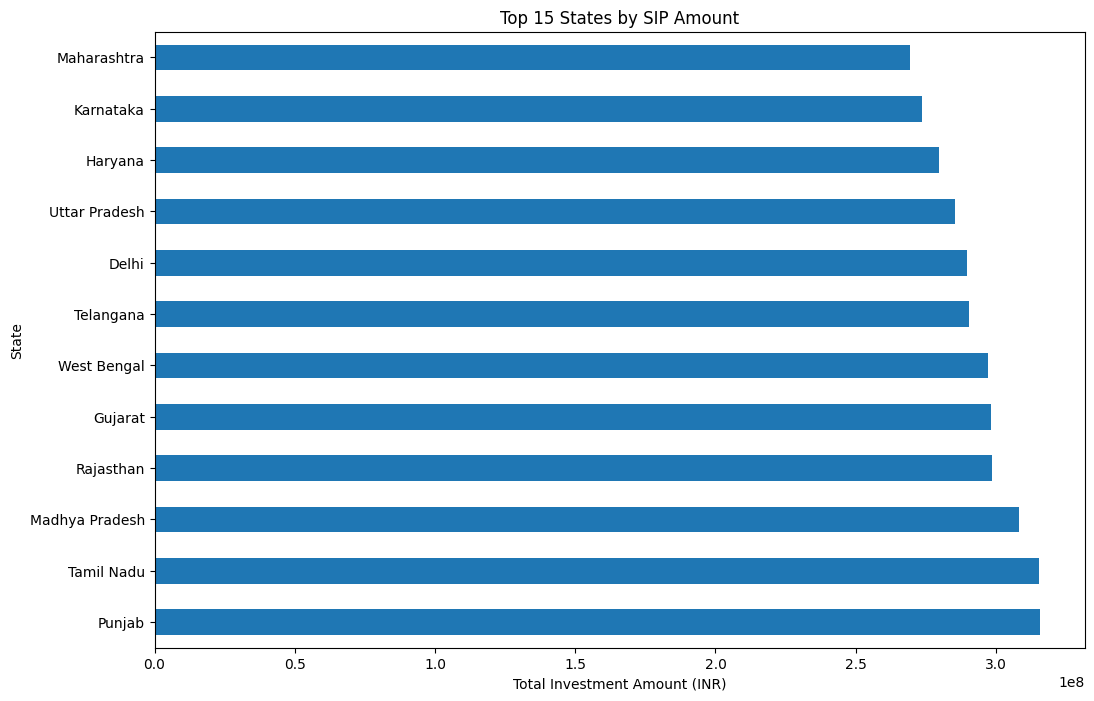

In [38]:
plt.figure(figsize=(12,8))

state_investment.head(15).plot(
    kind="barh"
)

plt.title("Top 15 States by SIP Amount")
plt.xlabel("Total Investment Amount (INR)")
plt.ylabel("State")

plt.show()

In [39]:
plt.savefig(
    "../reports/state_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

Insight 8

A small number of states contributed a disproportionately large share of SIP investments, indicating strong geographic concentration of mutual fund participation.

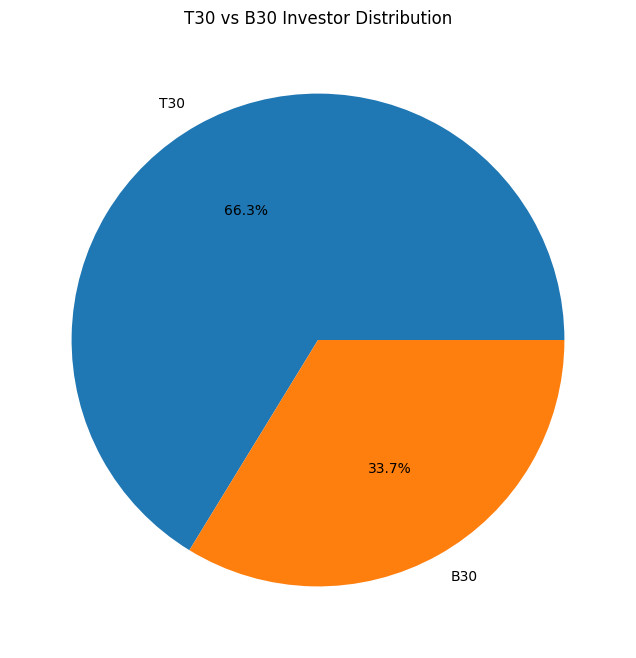

In [40]:
tier_dist = transactions["city_tier"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    tier_dist,
    labels=tier_dist.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")

plt.show()

In [41]:
plt.savefig(
    "../reports/t30_b30_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

Insight 9

Investor participation was distributed across both T30 and B30 cities, highlighting the increasing penetration of mutual funds beyond major metropolitan regions.

In [42]:
folio.head()
folio.columns

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')

In [44]:
folio["month"] = pd.to_datetime(folio["month"])

fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Industry Folio Growth (2022-2025)"
)

fig.show()

In [45]:
start = folio.iloc[0]
end = folio.iloc[-1]

fig.add_annotation(
    x=str(start["month"]),
    y=start["total_folios_crore"],
    text=f"{start['total_folios_crore']} Cr",
    showarrow=True
)

fig.add_annotation(
    x=str(end["month"]),
    y=end["total_folios_crore"],
    text=f"{end['total_folios_crore']} Cr",
    showarrow=True
)

fig.show()

In [47]:
fig.write_image(
    "../reports/folio_growth.png",
    width=1200,
    height=600
)

Resorting to unclean kill browser.


In [48]:
nav["date"] = pd.to_datetime(nav["date"])

pivot_nav = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot_nav.pct_change()

In [49]:
selected_returns = returns.iloc[:, :10]

In [50]:
corr_matrix = selected_returns.corr()

corr_matrix.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,0.027747,0.016053,-0.033773,-0.093533,-0.005867,-0.023316,-0.026781
100025,0.045567,1.000000,0.002150,0.023769,-0.006710,0.018455,-0.001038,0.013754,-0.005648,-0.014166
100033,-0.000006,0.002150,1.000000,-0.018079,0.000351,0.007864,-0.034228,-0.018166,-0.036647,-0.013318
101206,0.027747,0.023769,-0.018079,1.000000,0.010202,-0.027230,0.001570,0.007229,-0.006490,-0.005432
101207,0.016053,-0.006710,0.000351,0.010202,1.000000,-0.007530,-0.005929,0.004860,0.002304,0.043384


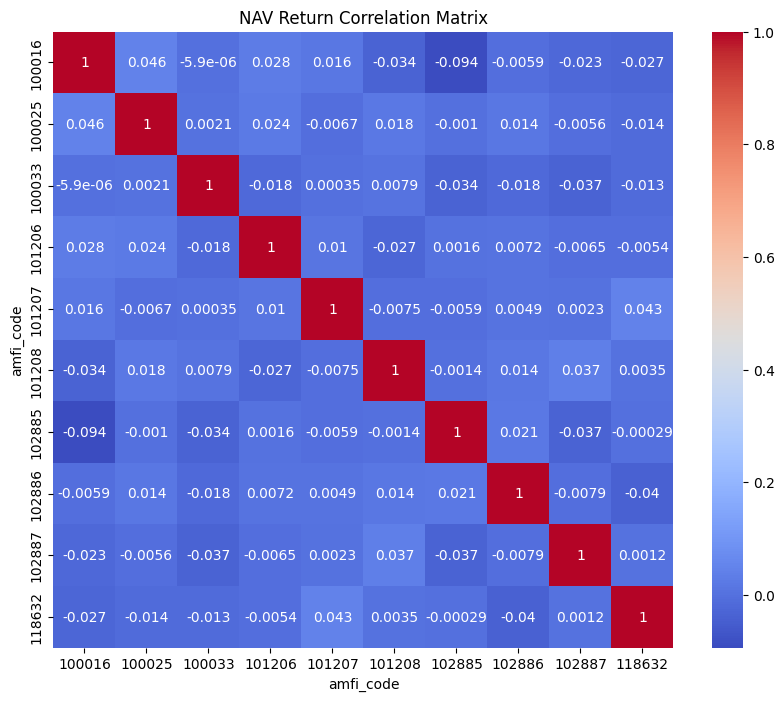

In [51]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation Matrix")

plt.show()

In [52]:
plt.savefig(
    "../reports/nav_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

Insight 11

Most selected mutual fund schemes exhibited positive return correlations, suggesting that market-wide factors influenced fund performance across categories.

In [53]:
holdings.columns


Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

In [54]:
sector_alloc = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

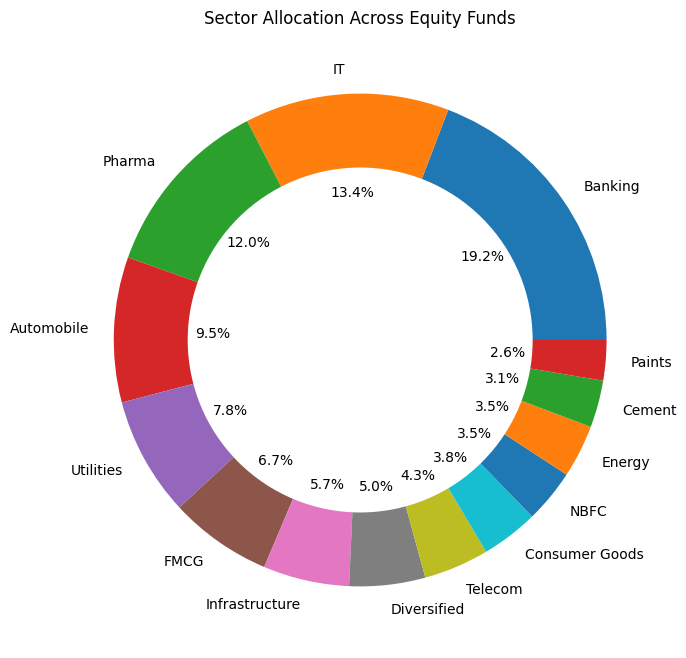

In [55]:
plt.figure(figsize=(8,8))

plt.pie(
    sector_alloc,
    labels=sector_alloc.index,
    autopct="%1.1f%%"
)

centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation Across Equity Funds")

plt.show()

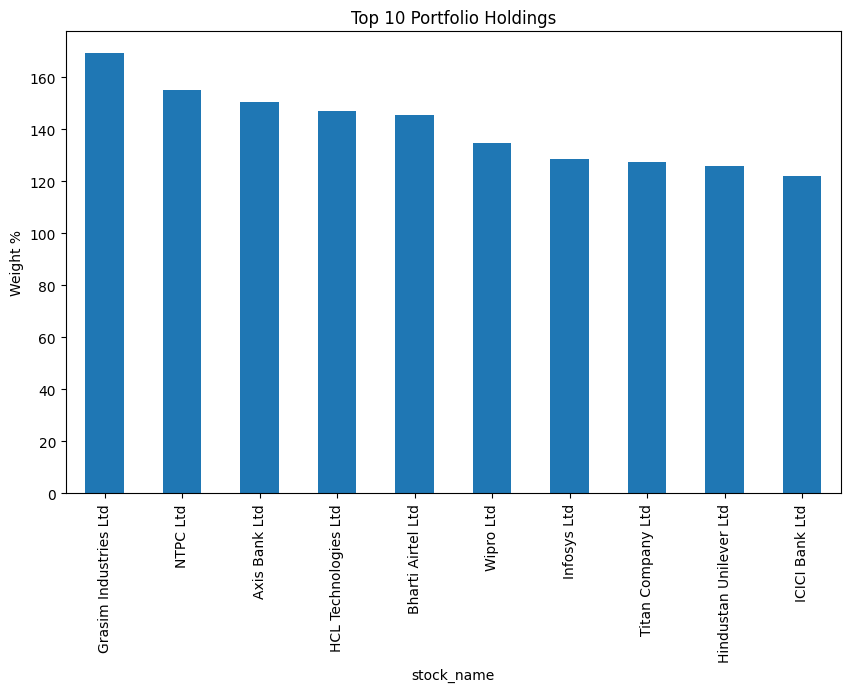

In [65]:
top_holdings = (
    holdings.groupby("stock_name")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

top_holdings.plot(kind="bar")

plt.title("Top 10 Portfolio Holdings")

plt.ylabel("Weight %")
plt.savefig(
    "../reports/Top_10_portfolio_holdings.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [66]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

fig = px.line(
    benchmark,
    x="date",
    y="close_value",
    color="index_name",
    title="Benchmark Index Performance"
)
plt.savefig(
    "../reports/Benchmark_Index_Performance.png",
    dpi=300,
    bbox_inches="tight"
)

fig.show()

<Figure size 640x480 with 0 Axes>

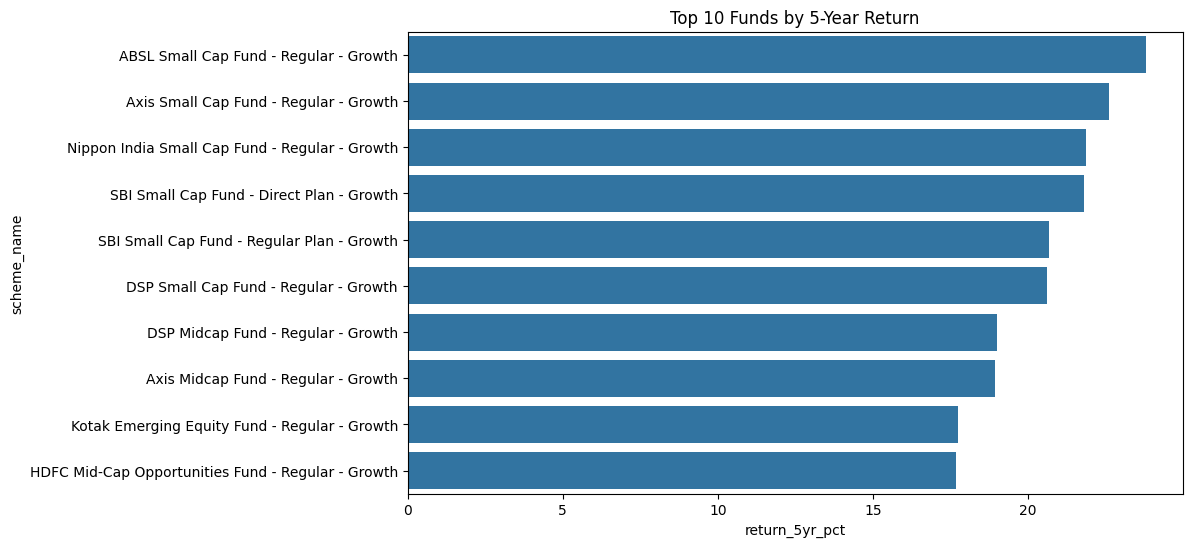

In [67]:
performance.head()
top_returns = performance.sort_values(
    by="return_5yr_pct",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_returns,
    x="return_5yr_pct",
    y="scheme_name"
)

plt.title("Top 10 Funds by 5-Year Return")
plt.savefig(
    "../reports/top_10_funds_by_5-year_return.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

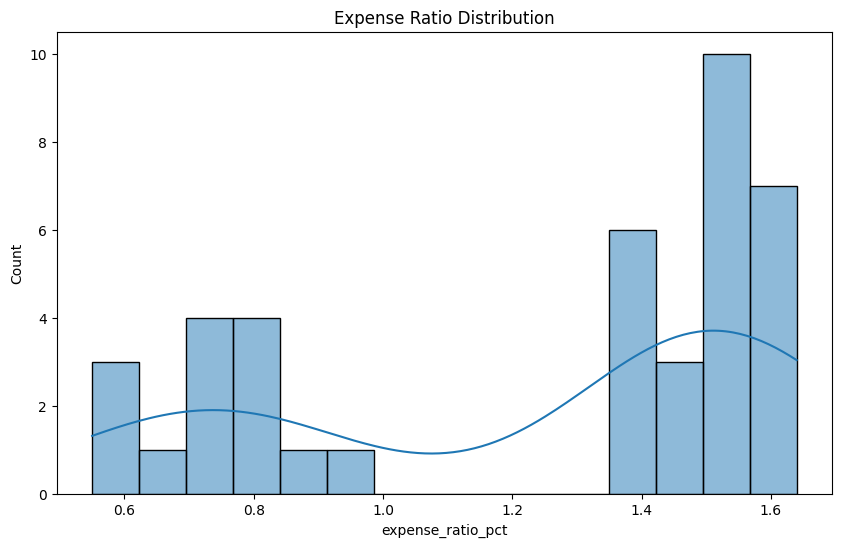

In [60]:
plt.figure(figsize=(10,6))

sns.histplot(
    performance["expense_ratio_pct"],
    bins=15,
    kde=True
)

plt.title("Expense Ratio Distribution")

plt.show()

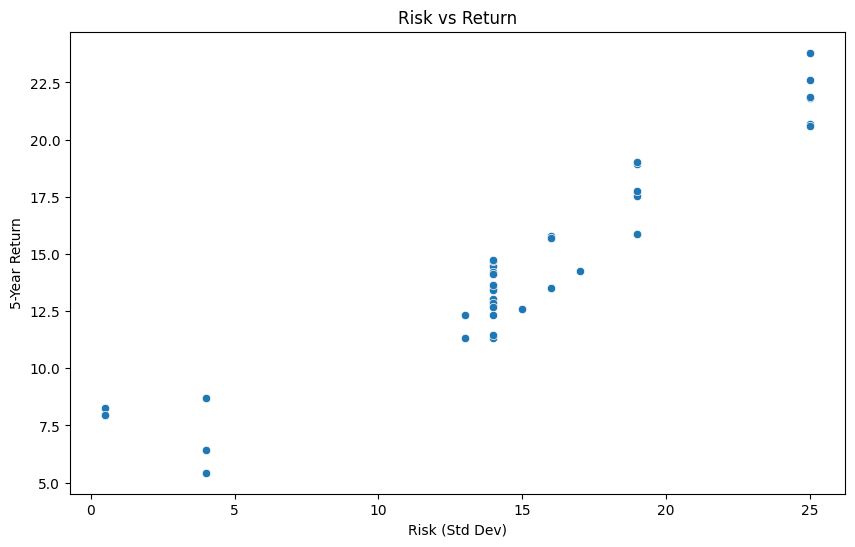

In [61]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=performance,
    x="std_dev_ann_pct",
    y="return_5yr_pct"
)

plt.title("Risk vs Return")

plt.xlabel("Risk (Std Dev)")
plt.ylabel("5-Year Return")

plt.show()

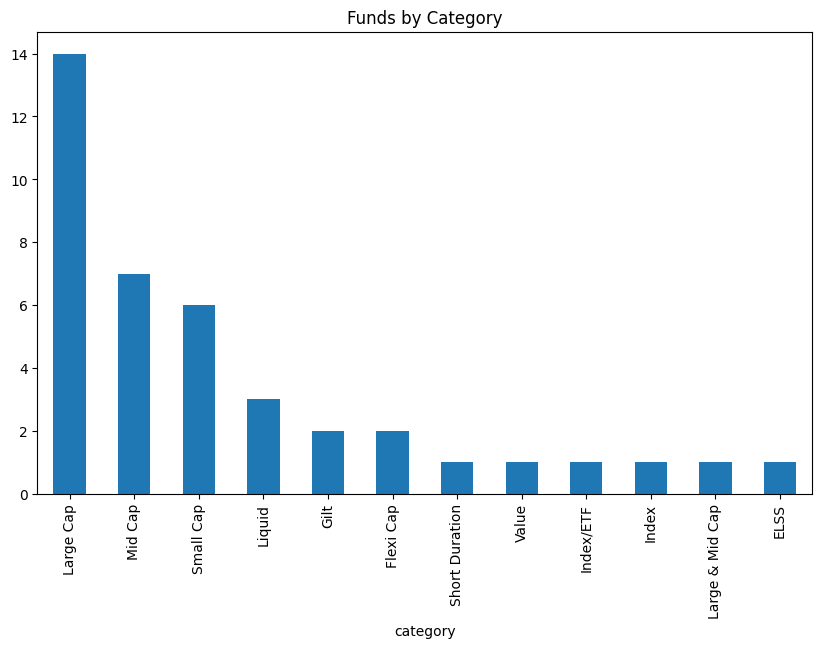

In [62]:
plt.figure(figsize=(10,6))

performance["category"].value_counts().plot(
    kind="bar"
)

plt.title("Funds by Category")

plt.show()

In [63]:
plt.savefig(
    "../reports/sector_allocation_donut.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [68]:
plt.savefig(
    "../reports/expense_ratio_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [69]:
plt.savefig(
    "../reports/risk_vs_return.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [70]:
plt.savefig(
    "../reports/fund_category_count.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [71]:
import os

os.listdir("../reports")

['age_boxplot.png',
 'age_distribution.png',
 'aum_growth_chart.png',
 'Benchmark_Index_Performance.png',
 'category_heatmap.png',
 'data_quality_summary.txt',
 'expense_ratio_distribution.png',
 'folio_growth.png',
 'fund_category_count.png',
 'gender_distribution.png',
 'nav_correlation_matrix.png',
 'risk_vs_return.png',
 'sector_allocation_donut.png',
 'sip_trend_chart.png',
 'state_distribution.png',
 't30_b30_distribution.png',
 'top_10_funds_by_5-year_return.png',
 'Top_10_portfolio_holdings.png']